# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Visualise Woodie's Pivots

In the previous video, we learned about an interesting kind of pivot points called the Woodies pivots. The Woodie's pivots generally work well when computed over longer timeframes and hence, are best suited for positional traders. In this notebook, let us calculate and visualise the Woodie's pivots for the close price series of Apple. 

The notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Import the Data](#libraries)
3. [Resample the Data](#resample)
4. [Get the Value of W-Pivot Level](#w-pivot)
5. [Get the Support and Resistance Levels](#s-r-levels)
6. [Visualise the Woodie's Pivots](#visualise)
7. [Conclusion](#conclusion)

<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# For datetime manipulation
from datetime import timedelta

# For plotting
import matplotlib.pyplot as plt
%matplotlib inline

<a id='data'></a>
## Import the Data

Once again, we will fetch the minute frequency data that is stored within the CSV file `apple_1_minute_2015_2021.csv`. You will find this CSV file in the zip file available in the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv('../data_modules/apple_1_minute_2015_2021.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Display the last 5 rows of the data
data.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.800,27.810
2015-01-02 09:31:00+00:00,27.8100,27.8475,27.785,27.825
2015-01-02 09:32:00+00:00,27.8250,27.8475,27.815,27.825
2015-01-02 09:33:00+00:00,27.8225,27.8250,27.780,27.795
2015-01-02 09:34:00+00:00,27.7950,27.8100,27.760,27.760


<a id='resample'></a>
## Resample the Data

The calculation of the Woodie's pivots will be performed on the weekly timeframe and further, we will visualise these levels over the daily frequency data. Hence, let us begin by resampling the minute level data into the daily and the weekly frequencies.

In [3]:
# Aggregate function
ohlcv_dict = {'Open': 'first',
              'High': 'max',
              'Low': 'min',
              'Close': 'last'
             }

# Resample the data to weekly frequency
data_weekly = data.resample('W-FRI', label='right', closed='left').agg(ohlcv_dict).dropna()
data_weekly.index += timedelta(hours=16, minutes=0)
data_weekly.tail()

,Open,High,Low,Close
2021-01-15 16:00:00+00:00,132.390,132.630,126.860,128.919
2021-01-22 16:00:00+00:00,128.699,139.670,126.930,136.860
2021-01-29 16:00:00+00:00,136.260,146.250,127.839,137.040
2021-02-05 16:00:00+00:00,135.850,137.584,130.210,137.390
2021-02-12 16:00:00+00:00,137.320,139.530,133.570,135.120


In [4]:
# Resample the data to daily frequency
data_daily = data.resample('1d', label='left', closed='right').agg(ohlcv_dict).dropna()
data_daily.index += timedelta(hours=16, minutes=0)
data_daily.tail()

,Open,High,Low,Close
2021-02-04 16:00:00+00:00,136.34,137.584,134.59,137.39
2021-02-05 16:00:00+00:00,137.32,139.530,135.86,136.77
2021-02-09 16:00:00+00:00,136.69,137.880,135.00,136.00
2021-02-10 16:00:00+00:00,136.48,136.990,134.40,135.36
2021-02-11 16:00:00+00:00,135.92,136.390,133.57,135.12


<a id='w-pivot'></a>
## Get the W-Pivot Level

Here we're going to compute the Woodie's pivot level (W-pivot) on the weekly frequency data for Apple (stored in `data_weekly`) based on the following formula:

$WPivot = \frac {High + Low + (2 * Close)}{4}$  

Where, **W Pivot** stands for the Woodie's pivot point. 

Note: In the following code cell, the `shift` function has been used because we will compute the pivot level based on the preceding candle's OHLC values.

In [5]:
# Initialise the previous high, low, close
prev_high = data_weekly['High'].shift(1)
prev_low = data_weekly['Low'].shift(1)
prev_close = data_weekly['Close'].shift(1)

# Calculate the Woodie's pivot level
data_weekly['W-Pivot'] = (prev_high + prev_low + (2*prev_close))/4

In the above code, we have computed the values of the Woodie's pivot level. Now, using the `W-pivot` we will calculate the three additional support and resistance levels. 

<a id='s-r-levels'></a>
## Get the Support and Resistance Levels

For the Woodie's pivots, the support and resistance levels can be computed by using the following formula:

* **R1** = (2 * P) – Low<br>
* **R2** = P + (High – Low)<br>
* **R3** = High + 2 * (P - Low)<br><br>
* **S1** = (2 * P) – High<br>
* **S2** = P – (High - Low)<br>
* **S3** = Low – 2 * (High – P)<br>

In [6]:
# Calculate the Woodie's resistance levels
data_weekly['R1'] = 2*data_weekly['W-Pivot'] - prev_low
data_weekly['R2'] = data_weekly['W-Pivot'] + (prev_high - prev_low)
data_weekly['R3'] = prev_high + 2*(data_weekly['W-Pivot'] - prev_low)

# Calculate the Woodie's support levels
data_weekly['S1'] = 2 * data_weekly['W-Pivot'] - prev_high
data_weekly['S2'] = data_weekly['W-Pivot'] - (prev_high - prev_low)
data_weekly['S3'] = prev_low - 2*(prev_high - data_weekly['W-Pivot'])

# Drop all NaN values from the dataframe
data_weekly.dropna(axis=0, how='any', inplace=True)

# Display the data
data_weekly.head()

,Open,High,Low,Close,W-Pivot,R1,R2,R3,S1,S2,S3
2015-01-16 16:00:00+00:00,28.1675,28.3125,26.6650,26.7075,27.532500,28.90750,29.412500,30.78750,27.02750,25.652500,25.14750
2015-01-23 16:00:00+00:00,26.7575,28.1175,26.3000,28.0975,27.098125,27.53125,28.745625,29.17875,25.88375,25.450625,24.23625
2015-01-30 16:00:00+00:00,28.0850,29.7975,27.2575,29.7325,27.653125,29.00625,29.470625,30.82375,27.18875,25.835625,25.37125
2015-02-06 16:00:00+00:00,29.6000,30.1275,29.0200,29.9850,29.130000,31.00250,31.670000,33.54250,28.46250,26.590000,25.92250
2015-02-13 16:00:00+00:00,30.0125,31.8700,29.6075,31.6050,29.779375,30.53875,30.886875,31.64625,29.43125,28.671875,28.32375


Now that all of the important Woodie's pivot levels have been calculated and stored in the respective columns in dataframe `data_weekly`, we can proceed to visualise the pivots over the data for recent days.

<a id='visualise'></a>
## Visualise the Woodie's Pivots

Let us now plot all of these important levels for the most recent trading date in our data. The levels can be plotted as horizontal lines over the daily close price series data of the Apple stock for a recent period.

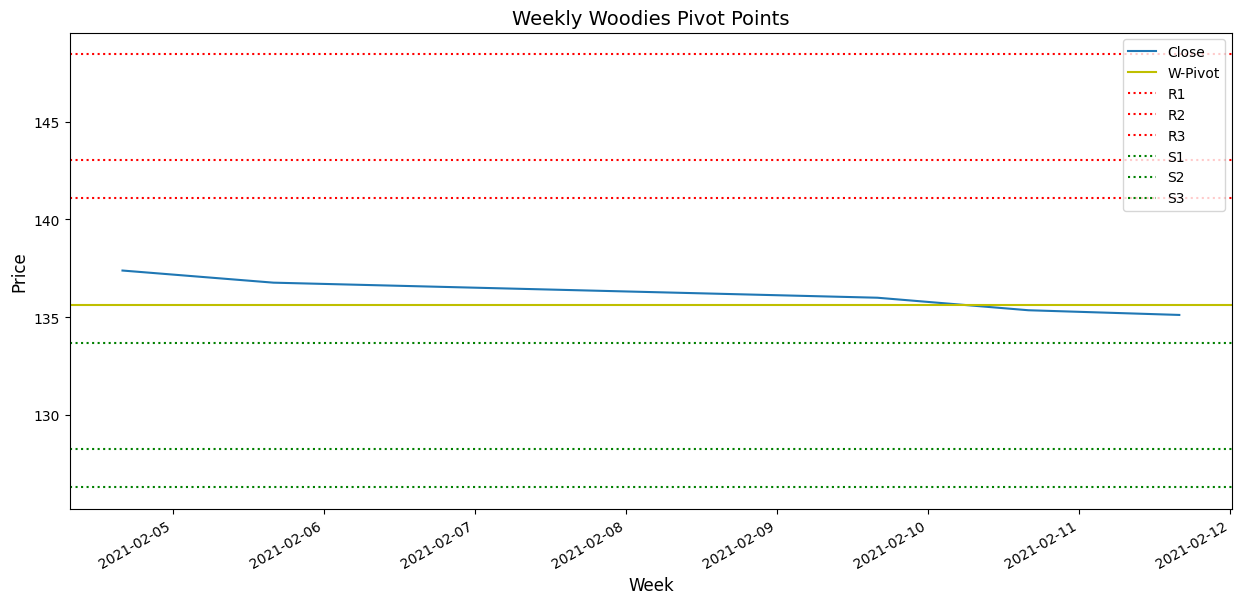

In [7]:
# Plot the close price for the recent 5 days
plt.figure(figsize=(15, 7))
data_daily.iloc[-5:]['Close'].plot()

# Plot the Woodies pivots
# For w-pivot level
plt.axhline(data_weekly.iloc[-1]['W-Pivot'], color='y', label="W-Pivot")

# For resistance levels
plt.axhline(data_weekly.iloc[-1]['R1'], color='r', linestyle=':', label="R1")
plt.axhline(data_weekly.iloc[-1]['R2'], color='r', linestyle=':', label="R2")
plt.axhline(data_weekly.iloc[-1]['R3'], color='r', linestyle=':', label="R3")

# For support levels
plt.axhline(data_weekly.iloc[-1]['S1'], color='g', linestyle=':', label="S1")
plt.axhline(data_weekly.iloc[-1]['S2'], color='g', linestyle=':', label="S2")
plt.axhline(data_weekly.iloc[-1]['S3'], color='g', linestyle=':', label="S3")

# Set the title and axes label
plt.title('Weekly Woodies Pivot Points', fontsize=14)
plt.xlabel('Week', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()

# Show the plot
plt.show()

<a id='conclusion'></a>
## Conclusion

So far you have learnt how to compute all of the important support and resistance levels based on the Woodie's pivots. And you have also learnt how to visualise the same. That's all for now. In the upcoming notebook, we will try and visualise the Camarilla pivot levels. <br><br>